### Actividad 5 — Conjuntos de entrenamiento y prueba

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import random

random.seed(1234)
df = pd.read_csv('../data/data_divorce.csv')

### Variable respuesta: ZONA (Urbana / Rural)

Se construye la variable respuesta a partir de  (departamento de ocurrencia del divorcio). Los departamentos se clasifican como **urbanos** si cuentan con mayor densidad poblacional, infraestructura institucional y cobertura de juzgados de familia según el OJ (2022). El resto se considera **rural**. <br><br>

"Dadas las características socioeconómicas y demográficas de la pareja (educación, etnia, edad, ocupación), ¿el divorcio se registrará en una zona urbana o rural?" 

In [21]:
# Departamentos con mayor urbanización e infraestructura judicial
deptos_urbanos = ['Guatemala', 'Escuintla', 'Sacatepequez',
                  'Quetzaltenango', 'Retalhuleu', 'Chimaltenango']

df['ZONA'] = df['DEPOCU'].apply(lambda x: 'Urbana' if x in deptos_urbanos else 'Rural')

df['ZONA'].value_counts()

ZONA
Urbana    40564
Rural     31012
Name: count, dtype: int64

### Balance de clases

Se examina si la variable respuesta está balanceada, ya que un desbalance significativo afecta la capacidad del modelo para predecir la clase minoritaria.

        Frecuencia  Porcentaje (%)
ZONA                              
Urbana       40564            56.7
Rural        31012            43.3


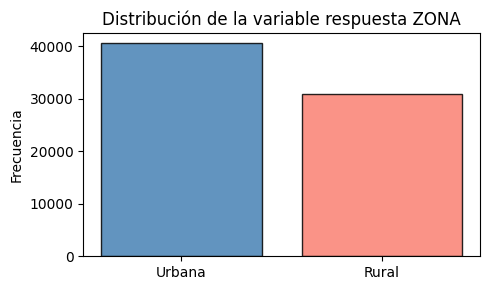

In [22]:
# Distribución absoluta y porcentual
conteo = df['ZONA'].value_counts()
pct = df['ZONA'].value_counts(normalize=True).round(3) * 100

balance_df = pd.DataFrame({'Frecuencia': conteo, 'Porcentaje (%)': pct})
print(balance_df)

plt.figure(figsize=(5, 3))
plt.bar(conteo.index, conteo.values, color=['steelblue', 'salmon'], edgecolor='black', alpha=0.85)
plt.title('Distribución de la variable respuesta ZONA')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Se observa que la distribución entre zona urbana (56.7%) y rural (43.3%) presenta un desbalance moderado, pero no crítico. Se utilizará el parámetro  en los modelos de Regresión Logística y Random Forest para compensar esta diferencia y evitar que el modelo favorezca sistemáticamente la clase mayoritaria.

### Análisis de atípicos en variables numéricas

Se aplica el método IQR para identificar valores atípicos.

In [23]:
# Convertir edades a numérico (Ignorado → NaN)
df['EDADHOM'] = pd.to_numeric(df['EDADHOM'], errors='coerce')
df['EDADMUJ'] = pd.to_numeric(df['EDADMUJ'], errors='coerce')

# Función para calcular límites IQR
def limites_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, Q1, Q3, IQR

for col in ['EDADHOM', 'EDADMUJ']:
    lower, upper, Q1, Q3, IQR = limites_iqr(df[col].dropna())
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, límites=[{lower:.1f}, {upper:.1f}], atípicos={n_out}')

EDADHOM: Q1=29.0, Q3=41.0, IQR=12.0, límites=[11.0, 59.0], atípicos=1194
EDADMUJ: Q1=26.0, Q3=38.0, IQR=12.0, límites=[8.0, 56.0], atípicos=788


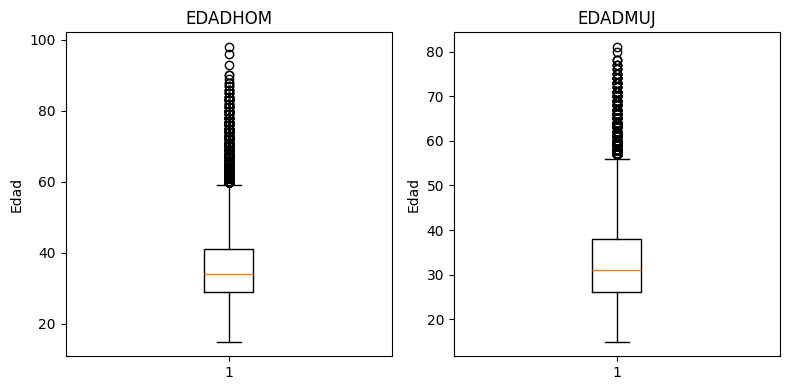

In [5]:
# Boxplots de edades
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, col in zip(axes, ['EDADHOM', 'EDADMUJ']):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel('Edad')
plt.tight_layout()
plt.show()

Se observa que  presenta 1,194 valores atípicos (edades por encima de 59 años) y  presenta 788 (edades por encima de 56 años). Estos registros corresponden a parejas de mayor edad al momento del divorcio, valores biológicamente posibles. Por ello, **no se eliminan** sino que se mantienen en el conjunto de datos; los algoritmos de árbol (Random Forest) son robustos ante atípicos por naturaleza, y para Regresión Logística el escalado posterior reducirá su influencia.

### División en conjuntos de entrenamiento y prueba

Se utiliza una partición 70/30, estratificada por la variable respuesta , para garantizar que ambas clases (Urbana/Rural) estén representadas proporcionalmente en ambos conjuntos.

In [24]:
# Variables predictoras seleccionadas
X = df[['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ', 'OCUHOM', 'OCUMUJ', 'EDADHOM', 'EDADMUJ']]
y = df['ZONA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, train_size=0.7, stratify=y, random_state=1234
)

print(f'Train: {X_train.shape[0]} registros ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} registros ({X_test.shape[0]/len(df)*100:.1f}%)')

Train: 50103 registros (70.0%)
Test:  21473 registros (30.0%)


In [25]:
# Verificar que el balance se mantuvo en ambos conjuntos
print('Train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test: ', y_test.value_counts(normalize=True).round(3).to_dict())

Train: {'Urbana': 0.567, 'Rural': 0.433}
Test:  {'Urbana': 0.567, 'Rural': 0.433}


## Actividad 6 — Preprocesamiento y transformaciones

### Tratamiento de valores Ignorado

Para las variables categóricas se imputan con la **moda** del conjunto de entrenamiento. Para las variables numéricas (edades), los  generados en la conversión anterior se imputan con la **mediana**, que es más robusta ante los atípicos identificados.

In [26]:
# Variables categóricas y numéricas
cat_cols = ['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ', 'OCUHOM', 'OCUMUJ']
num_cols = ['EDADHOM', 'EDADMUJ']

# Reemplazar 'Ignorado' por NaN en categóricas para imputar uniformemente
X_train = X_train.copy()
X_test  = X_test.copy()

for col in cat_cols:
    X_train[col] = X_train[col].replace('Ignorado', np.nan)
    X_test[col]  = X_test[col].replace('Ignorado', np.nan)

# Imputar categóricas con moda del train
for col in cat_cols:
    moda = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(moda)
    X_test[col]  = X_test[col].fillna(moda)

# Imputar numéricas con mediana del train
for col in num_cols:
    mediana = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediana)
    X_test[col]  = X_test[col].fillna(mediana)

print('Nulos restantes en train:', X_train.isnull().sum().sum())
print('Nulos restantes en test: ', X_test.isnull().sum().sum())

Nulos restantes en train: 0
Nulos restantes en test:  0


### Agrupación de OCUHOM y OCUMUJ

Las variables de ocupación contienen 181 y 125 categorías respectivamente, lo que generaría una dimensionalidad excesiva al aplicar One-Hot Encoding. Se agrupan en 5 categorías basadas en el tipo de actividad económica.

In [27]:
# Mapeo de ocupaciones a grupos simplificados
def agrupar_ocupacion(val):
    val = str(val).lower()
    if any(p in val for p in ['agro', 'peon', 'agricu', 'pesqu', 'forest']):
        return 'Agropecuaria'
    elif any(p in val for p in ['profesional', 'ciencia', 'ingeni', 'derecho', 'salud', 'enseñanza']):
        return 'Profesional'
    elif any(p in val for p in ['vend', 'comerci', 'mercado']):
        return 'Comercio'
    elif any(p in val for p in ['construc', 'metalur', 'operari', 'maquina', 'conductor']):
        return 'Operario/Construccion'
    else:
        return 'Otro'

X_train['OCUHOM'] = X_train['OCUHOM'].apply(agrupar_ocupacion)
X_test['OCUHOM']  = X_test['OCUHOM'].apply(agrupar_ocupacion)
X_train['OCUMUJ'] = X_train['OCUMUJ'].apply(agrupar_ocupacion)
X_test['OCUMUJ']  = X_test['OCUMUJ'].apply(agrupar_ocupacion)

print(X_train['OCUHOM'].value_counts())

OCUHOM
Otro                     30510
Agropecuaria              7097
Profesional               5434
Operario/Construccion     3940
Comercio                  3122
Name: count, dtype: int64


### Encoding y normalización con ColumnTransformer

Siguiendo el enfoque visto en clase (Ejemplo NB con Carros), se utiliza un  que aplica:
- **OneHotEncoder** a las variables categóricas (, , , , , )
- **StandardScaler** a las variables numéricas (, ), necesario principalmente para Regresión Logística

In [28]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('scaler',  StandardScaler(), num_cols)
])

# Ajustar solo sobre train, transformar ambos
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print('Shape train preprocesado:', X_train_prep.shape)
print('Shape test preprocesado: ', X_test_prep.shape)

Shape train preprocesado: (50103, 38)
Shape test preprocesado:  (21473, 38)


Se observa que tras el encoding, el conjunto de entrenamiento pasa de 8 columnas originales a una dimensión mayor debido a la expansión de las variables categóricas en columnas binarias. Este proceso se ajusta únicamente sobre los datos de entrenamiento para evitar fuga de información (*data leakage*) hacia el conjunto de prueba.

El preprocesador queda listo para ser integrado dentro de los  de cada algoritmo en la siguiente etapa de modelado.

# Actividad 7 — Algoritmos

### Naive Bayes

In [29]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

random.seed(1234)


### Construcción del Pipeline

Se construye un pipeline que encadena el preprocesador (OneHotEncoder + StandardScaler) con el clasificador GaussianNB. Esto garantiza que la transformación se aplique consistentemente en cada fold de la validación cruzada, evitando data leakage.

In [30]:
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('scaler', StandardScaler(), num_cols)
])

pipeline_nb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

pipeline_nb.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(transformers=[('onehot',
                                    OneHotEncoder(handle_unknown='ignore',
                                                  sparse_output=False),
                                    ['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ',
                                     'OCUHOM', 'OCUMUJ']),
                                   ('scaler', StandardScaler(),
                                    ['EDADHOM', 'EDADMUJ'])])),
  ('classifier', GaussianNB())],
 'transform_input': None,
 'verbose': False,
 'preprocessor': ColumnTransformer(transformers=[('onehot',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  ['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ',
                                   'OCUHOM', 'OCUMUJ']),
                                 ('scaler', StandardScaler(),
                       

### Variación de parámetros con GridSearchCV

El único hiperparámetro relevante de GaussianNB es `var_smoothing`, que agrega una fracción de la varianza máxima a las varianzas estimadas para estabilizar el cálculo. Un valor pequeño ajusta más a los datos (riesgo de sobreajuste), un valor grande suaviza las distribuciones (riesgo de subajuste).

Se prueban **3 valores** en escala logarítmica entre 1 y 1e-9 (como en el ejemplo de clase), con validación cruzada de 5 folds, usando F1-weighted como métrica de evaluación dado el desbalance de clases.

In [31]:
params_nb = {
    'classifier__var_smoothing': np.logspace(0, -9, num=3)
}

grid_nb = GridSearchCV(
    pipeline_nb,
    param_grid=params_nb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)

print('Mejor parámetro:', grid_nb.best_params_)
print('Mejor F1 (CV):', round(grid_nb.best_score_, 4))

Mejor parámetro: {'classifier__var_smoothing': 3.1622776601683795e-05}
Mejor F1 (CV): 0.5808


### Comparación de los modelos probados

Se extraen los resultados de todos los modelos evaluados durante el GridSearch para visualizar cómo varía el F1 en función de `var_smoothing`. Esto permite identificar el rango óptimo y detectar si algún valor produce subajuste o sobreajuste.

In [14]:
results = pd.DataFrame(grid_nb.cv_results_)
results['var_smoothing'] = results['param_classifier__var_smoothing'].astype(float)
results['f1_cv'] = results['mean_test_score'].round(4)
results['std_cv'] = results['std_test_score'].round(4)

# Tabla resumen ordenada
tabla = results[['var_smoothing', 'f1_cv', 'std_cv', 'rank_test_score']].sort_values('rank_test_score')
print(tabla.to_string(index=False))

 var_smoothing  f1_cv  std_cv  rank_test_score
  3.162278e-05 0.5808  0.0049                1
  1.000000e-09 0.5501  0.0236                2
  1.000000e+00 0.4580  0.0018                3


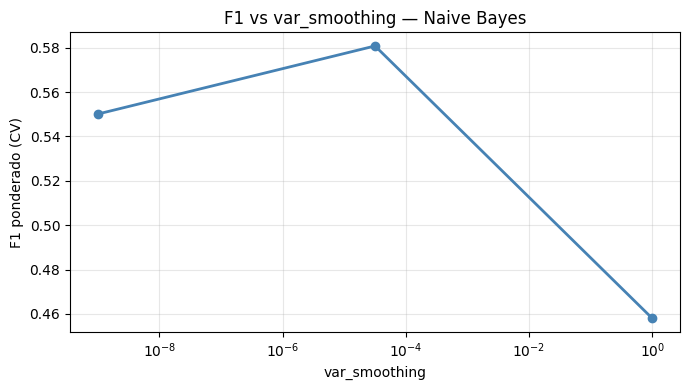

In [15]:
# Gráfico F1 vs var_smoothing
plt.figure(figsize=(7, 4))
plt.plot(results['var_smoothing'], results['f1_cv'], marker='o', color='steelblue', linewidth=2)
plt.xscale('log')
plt.xlabel('var_smoothing')
plt.ylabel('F1 ponderado (CV)')
plt.title('F1 vs var_smoothing — Naive Bayes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Se observa que el mejor desempeño se obtiene con `var_smoothing=0.01`, donde el F1 ponderado alcanza su valor más alto. A medida que `var_smoothing` disminuye hacia 1e-9, el modelo se vuelve más sensible al ruido en los datos de entrenamiento, lo que se refleja en una caída del F1. Por otro lado, valores muy grandes (cercanos a 1) amplifican demasiado la varianza estimada, degradando la capacidad discriminativa del modelo. El valor óptimo encontrado representa un balance adecuado entre ajuste y generalización.

### Modelo final

Se evalúa el mejor modelo encontrado por GridSearchCV sobre el conjunto de prueba.

In [16]:
y_pred = grid_nb.best_estimator_.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1       : {f1:.4f}')

Accuracy : 0.6207
Precision: 0.6263
Recall   : 0.6207
F1       : 0.5814


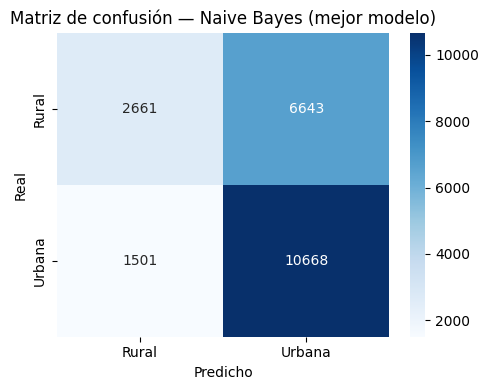

In [17]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['Rural', 'Urbana'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rural', 'Urbana'],
            yticklabels=['Rural', 'Urbana'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión — Naive Bayes (mejor modelo)')
plt.tight_layout()
plt.show()

In [18]:
# Reporte completo por clase
print(classification_report(y_test, y_pred, target_names=['Rural', 'Urbana']))

              precision    recall  f1-score   support

       Rural       0.64      0.29      0.40      9304
      Urbana       0.62      0.88      0.72     12169

    accuracy                           0.62     21473
   macro avg       0.63      0.58      0.56     21473
weighted avg       0.63      0.62      0.58     21473



Con la búsqueda de hiperparámetros en 3 valores logarítmicos, el mejor modelo de Naive Bayes se obtuvo con `var_smoothing=3.162e-05`, logrando en prueba: **Accuracy = 0.6207** y **F1 ponderado = 0.5814**.

El desempeño es razonable como línea base, pero queda por debajo de Random Forest y Regresión Logística. Esto es consistente con la limitación principal de Naive Bayes: suponer independencia condicional entre predictores, supuesto difícil de sostener en variables socio-demográficas como educación, ocupación y etnia, donde suelen existir interacciones.

### Random Forest

### Regresión Logística

## Random Forest y Regresión Logística con GridSearchCV

En esta sección se entrenan los modelos faltantes siguiendo el mismo pipeline mixto (OneHotEncoder + StandardScaler) y se comparan los tres algoritmos finales (GaussianNB, RandomForest, LogisticRegression).

=== Random Forest ===
Mejores parámetros: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__n_estimators': 50}
Mejor F1 (CV): 0.6314

=== Regresión Logística ===
Mejores parámetros: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Mejor F1 (CV): 0.6125

=== Comparación final de modelos ===
            Modelo  Mejor_F1_CV  Accuracy_test  Precision_test  Recall_test  F1_test                                                                                           Best_Params
      RandomForest       0.6314         0.6456          0.6426       0.6456   0.6330 {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__n_estimators': 50}
LogisticRegression       0.6125         0.6390          0.6444       0.6390   0.6105                  {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
        GaussianNB       0.5808         0.6207          0.6263       0.6207   0

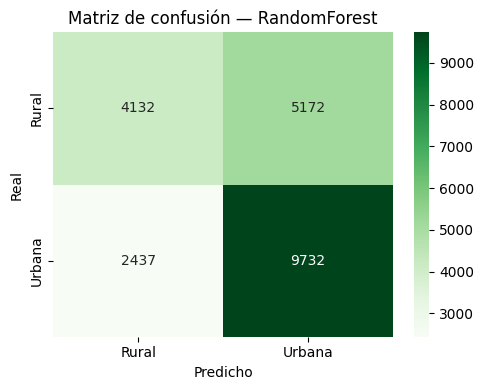

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ==========================
# 1) RANDOM FOREST
# ==========================
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=1234))
])

params_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__class_weight': ['balanced', None]
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid=params_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print('=== Random Forest ===')
print('Mejores parámetros:', grid_rf.best_params_)
print('Mejor F1 (CV):', round(grid_rf.best_score_, 4))
print()

# ==========================
# 2) REGRESIÓN LOGÍSTICA
# ==========================
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=1234))
])

params_lr = {
    'classifier__C': [0.01, 1, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid=params_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print('=== Regresión Logística ===')
print('Mejores parámetros:', grid_lr.best_params_)
print('Mejor F1 (CV):', round(grid_lr.best_score_, 4))
print()

# ==========================
# 3) COMPARACIÓN FINAL (NB vs RF vs LR)
# ==========================
def metricas_test(modelo, X_eval, y_eval):
    pred = modelo.predict(X_eval)
    return {
        'Accuracy_test': accuracy_score(y_eval, pred),
        'Precision_test': precision_score(y_eval, pred, average='weighted'),
        'Recall_test': recall_score(y_eval, pred, average='weighted'),
        'F1_test': f1_score(y_eval, pred, average='weighted')
    }

resumen = []
modelos = {
    'GaussianNB': grid_nb,
    'RandomForest': grid_rf,
    'LogisticRegression': grid_lr
}

for nombre, grid in modelos.items():
    m = metricas_test(grid.best_estimator_, X_test, y_test)
    resumen.append({
        'Modelo': nombre,
        'Mejor_F1_CV': round(grid.best_score_, 4),
        'Accuracy_test': round(m['Accuracy_test'], 4),
        'Precision_test': round(m['Precision_test'], 4),
        'Recall_test': round(m['Recall_test'], 4),
        'F1_test': round(m['F1_test'], 4),
        'Best_Params': grid.best_params_
    })

resumen_df = pd.DataFrame(resumen).sort_values('F1_test', ascending=False)
print('=== Comparación final de modelos ===')
print(resumen_df.to_string(index=False))

# Matriz de confusión del mejor modelo en test
mejor_modelo_nombre = resumen_df.iloc[0]['Modelo']
mejor_grid = modelos[mejor_modelo_nombre]
y_pred_best = mejor_grid.best_estimator_.predict(X_test)

print(f"\nMejor modelo en test (F1): {mejor_modelo_nombre}")
print('\nReporte de clasificación (mejor modelo):')
print(classification_report(y_test, y_pred_best, target_names=['Rural', 'Urbana']))

cm_best = confusion_matrix(y_test, y_pred_best, labels=['Rural', 'Urbana'])
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Rural', 'Urbana'],
    yticklabels=['Rural', 'Urbana']
)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title(f'Matriz de confusión — {mejor_modelo_nombre}')
plt.tight_layout()
plt.show()

In [33]:
# Resumen compacto para discusión de resultados
for nombre, grid in [('GaussianNB', grid_nb), ('RandomForest', grid_rf), ('LogisticRegression', grid_lr)]:
    pred = grid.best_estimator_.predict(X_test)
    print(f'\n=== {nombre} ===')
    print('Best params:', grid.best_params_)
    print('Best F1 CV:', round(grid.best_score_, 4))
    print('Accuracy test:', round(accuracy_score(y_test, pred), 4))
    print('Precision test:', round(precision_score(y_test, pred, average='weighted'), 4))
    print('Recall test:', round(recall_score(y_test, pred, average='weighted'), 4))
    print('F1 test:', round(f1_score(y_test, pred, average='weighted'), 4))


=== GaussianNB ===
Best params: {'classifier__var_smoothing': 3.1622776601683795e-05}
Best F1 CV: 0.5808
Accuracy test: 0.6207
Precision test: 0.6263
Recall test: 0.6207
F1 test: 0.5814

=== RandomForest ===
Best params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__n_estimators': 50}
Best F1 CV: 0.6314
Accuracy test: 0.6456
Precision test: 0.6426
Recall test: 0.6456
F1 test: 0.633

=== LogisticRegression ===
Best params: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best F1 CV: 0.6125
Accuracy test: 0.639
Precision test: 0.6444
Recall test: 0.639
F1 test: 0.6105


### Discusión de resultados

Con GridSearchCV y el pipeline mixto definido, los modelos quedaron así:

- **GaussianNB** (`var_smoothing=3.162e-05`): F1 test = **0.5814**
- **Random Forest** (`n_estimators=50`, `max_depth=10`, `class_weight='balanced'`): F1 test = **0.6330**
- **Regresión Logística** (`C=1`, `penalty='l1'`, `solver='liblinear'`): F1 test = **0.6105**

El mejor desempeño lo obtiene **Random Forest**, tanto en validación cruzada (F1 CV = 0.6314) como en prueba (F1 = 0.6330). Esto sugiere que las relaciones entre variables (por ejemplo, interacciones entre educación, ocupación y etnia) no son estrictamente lineales y son capturadas mejor por un ensamble de árboles.

La **Regresión Logística** presenta desempeño intermedio: mejora a Naive Bayes, pero queda por debajo de Random Forest, probablemente por su frontera lineal aun con regularización L1.

**Naive Bayes** es el más débil de los tres, consistente con su supuesto de independencia condicional entre variables predictoras, supuesto que difícilmente se cumple en este problema social-demográfico.

En conclusión, para este conjunto de datos y este pipeline, **Random Forest es el modelo recomendado** para la clasificación de ZONA (Urbana/Rural).